## Train

In [1]:
%%capture
import matplotlib.pyplot as plt
from ptycho_torch.inference import reconstruct
from ptycho_torch.train import train

data = "datasets/Run1084_recon3_postPC_shrunk_3.npz"
model = train(data, "outputs/run1084_cnn", {
    "architecture": "cnn",
    "training_groups": 512,
    "nphotons": 1e9,
    "epochs": 50,
})

## Inference

In [11]:
result = reconstruct(model, data, device = 'cuda')

Decoder Block 1: No attention module added.
Decoder Block 2: No attention module added.
Decoder Block 1: No attention module added.
Decoder Block 2: No attention module added.
Decoder Block 1: No attention module added.
Decoder Block 2: No attention module added.
Decoder Block 1: No attention module added.
Decoder Block 2: No attention module added.
Calculating dataset length with coordinate bounds...
For file /tmp/barycentric-workspace-rn802n3y/staged/Run1084_recon3_postPC_shrunk_3.npz, maximum x_range is (34.41161595623848, 79.28087207942583), yrange is (35.76291640620743, 79.10709370020433)
Creating memory mapped tensor dictionary...
Memory map length: 722
Memory map creation time: 0.021851062774658203
Populating memory map for dataset 0
Start - end = 722
Non-diffraction memory map write time: 0.06500983238220215
Diffraction memory map write time: 0.011298894882202148
[PtychoDataset Rank 0] Initialization successful. Dataset length: 722.
Reassembly route: barycentric (patch_weightin

## Plotting

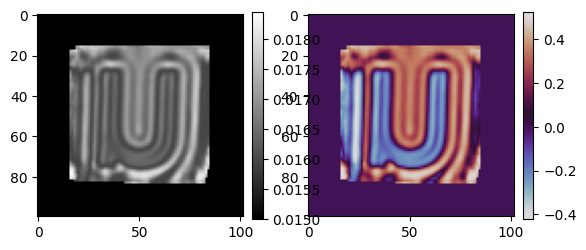

In [14]:
figure, axes = plt.subplots(1, 2)

im0 = axes[0].imshow(result.amplitude, cmap="gray", vmin=0.015)
figure.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04)

im1 = axes[1].imshow(result.phase, cmap="twilight")
figure.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)

plt.show()

### Print configs

In [17]:
from dataclasses import asdict
from pprint import pprint
from ptycho_torch.workflows.components import load_inference_bundle_torch

models, loaded_config = load_inference_bundle_torch(model.parent)
trained_model = models["diffraction_to_obj"]

#pprint(asdict(trained_model.model_config))
# pprint(asdict(trained_model.data_config))
pprint(asdict(trained_model.training_config))
# pprint(asdict(trained_model.inference_config))


Decoder Block 1: No attention module added.
Decoder Block 2: No attention module added.
Decoder Block 1: No attention module added.
Decoder Block 2: No attention module added.
Decoder Block 1: No attention module added.
Decoder Block 2: No attention module added.
Decoder Block 1: No attention module added.
Decoder Block 2: No attention module added.
{'accum_steps': 1,
 'adam_beta1': 0.9,
 'adam_beta2': 0.999,
 'batch_size': 16,
 'device': 'cuda',
 'epochs': 50,
 'epochs_fine_tune': 0,
 'experiment_name': 'Synthetic_Runs',
 'fine_tune_gamma': 0.1,
 'framework': 'Lightning',
 'grad_norm_log_freq': 1,
 'gradient_clip_algorithm': 'norm',
 'gradient_clip_val': None,
 'learning_rate': 0.001,
 'log_grad_norm': False,
 'lr_min_ratio': 0.1,
 'lr_warmup_epochs': 0,
 'model_name': 'PtychoPINNv2',
 'momentum': 0.9,
 'n_devices': 1,
 'nll': True,
 'notes': '',
 'num_workers': 4,
 'optimizer': 'adam',
 'orchestrator': 'Mlflow',
 'output_dir': 'outputs/run1084_cnn',
 'physics_weight_schedule': 'cosin

In [1]:

from dataclasses import asdict
from ptycho_torch.workflows.components import load_inference_bundle_torch

bundle = train(data, "outputs/run1084_cnn", {
    "architecture": "cnn",
    "training_groups": 512,
    "nphotons": 1e9,
    "epochs": 1,
})

models, loaded_config = load_inference_bundle_torch(bundle.parent)
module = models["lightning_module"]

configs = {
    "model": module.model_config,
    "data": module.data_config,
    "training": module.training_config,
    "inference": module.inference_config,
}

for name, config in configs.items():
    print(name, asdict(config))


NameError: name 'train' is not defined

In [2]:
result = reconstruct(model, data)
figure, axes = plt.subplots(1, 2)
axes[0].imshow(result.amplitude, cmap="gray")
axes[1].imshow(result.phase, cmap="twilight")
plt.show()

NameError: name 'model' is not defined